In [123]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv("C:\\Users\\Hp\\Downloads\\clustering_data.csv") # Importing the data using .read_csv
# print(data)
df=data.loc[data['StateName']=='ANDHRA PRADESH'] # Selecting data related to my home state
print(df.head())
print(df.shape)

              CircleName      RegionName       DivisionName  \
0  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
1  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
2  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
3  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
4  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   

            OfficeName  Pincode OfficeType  Delivery   District  \
0       Peddakotla B.O   515631         BO  Delivery  ANANTAPUR   
1       Pinnadhari B.O   515631         BO  Delivery  ANANTAPUR   
2  Yerraguntapalle B.O   515631         BO  Delivery  ANANTAPUR   
3  Obulareddipalli B.O   515581         BO  Delivery  ANANTAPUR   
4       Odulapalli B.O   515581         BO  Delivery  ANANTAPUR   

        StateName   Latitude  Longitude  
0  ANDHRA PRADESH    14.5689   77.85624  
1  ANDHRA PRADESH    14.5281  77.857014  
2  ANDHRA PRADESH  14.561111   77.85715  
3  ANDHRA PRADESH    14.2488    78.2588  
4  ANDHR

C:\Users\Hp\AppData\Local\Temp\ipykernel_17296\3236368667.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("C:\\Users\\Hp\\Downloads\\clustering_data.csv")


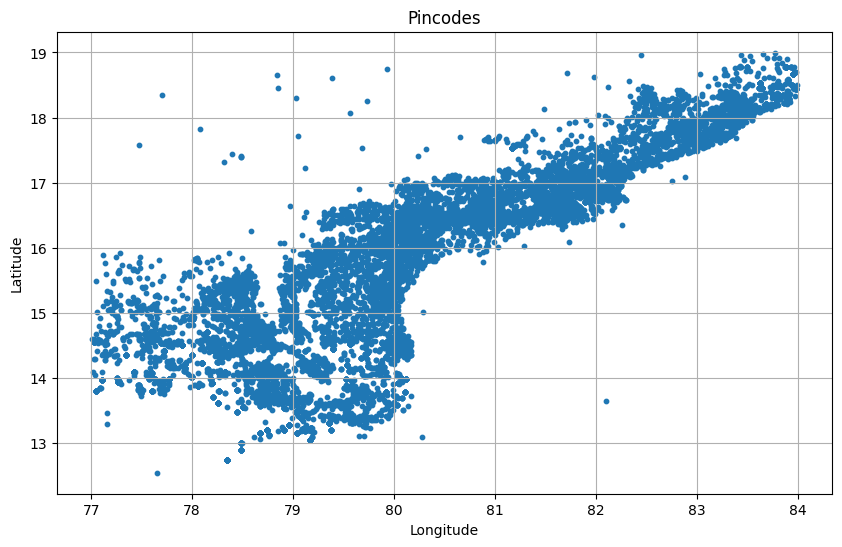

In [ ]:
X=df.loc[:,["Latitude","Longitude"]].astype(float) # Selecting only specific columns latitudes and lonitudes which are useful
X=X.dropna() # Data cleaning removing null values
X=X.loc[(X['Latitude']>12)&(X['Latitude']<19)&(X['Longitude']>77)&(X['Longitude']<84)] # removing the data which is not geographically belonging to my home state
X=X.to_numpy() # Converting to a numpy array for further operations

# Data visualization using scatter plot
plt.figure(figsize=(10,6))
plt.scatter(x=X[:,1],y=X[:,0],s=10)
plt.ylabel("Latitude")
plt.xlabel("Longitude")
plt.title("Pincodes")
plt.grid(True)
plt.show()

In [ ]:
# Function used to assign labels to the data points
def assign_labels(centroids,ds):
  clus=[] # Creating a list which stores my labels 
  for points in ds:
    dis=[] # Creating list which stores the distance between each centroid and the data point
    for i in centroids:
      dis.append(np.linalg.norm(points-i)) # We use euclidian distance here
    clus.append(dis.index(min(dis))) # Assigning the cluster to the datapoint by checking the nearest centroid
  return clus

# Function to update the centroids to the mean of the datapoints so that eventually the final centroids get saturated over the iterations
def update_centroids(ds,lab,k):
  new_cen=[] # Creating list which will save the new centroids created
  for i in range(k):
    sum=np.array([0.00,0.00])
    c=0
    for idx in range(len(lab)):
      if lab[idx]==i:
        c+=1
        sum+=ds[idx]
    new_cen.append(sum/c) # Finding the mean of the datapoints in a particular cluster and assigning as the new centroid
  return new_cen

final_cen=[] # Creating a list so that it contains the best centroids for different values of k 

variance=[] # Creating a list which contains the variance of the K-Means clusters for  different values of K ehich is used for Elbow graph later

for k in range(1,6): # Taking k values only between 1-6 (This is user friendly you can decide any thing you want)
  
  best_var=10000000.000 # Initializing the best variance to the higest value possible so that it can be used to find the best centroids
  
  best_lab=[] # It contains the labels of the datapoints corressponding to best centroids
  
  best_cen=[] # This contains the best centroids for a particular value of k which will eventually get stored in final_cen
  
  for _ in range(5): # Initializing the random centroids different times so that we can get the bet clustering
    centroids=X[np.random.choice(X.shape[0],k,replace=False)]
    
    for _ in range(100): # Updating the centroids until they get saturated
      labels=assign_labels(centroids,X)
      new_centroids=update_centroids(X,labels,k)
      
      if np.allclose(centroids,new_centroids): # np.allclose is used to say are the two arrays almost equal to each other
        break
      else:
        centroids=new_centroids
    var=0
    
    for idx in range(len(labels)):
      var+=np.linalg.norm(X[idx]-centroids[labels[idx]])**2 # Finding variance for the centroids which were saturated
    
    if var<best_var: # Always finding the centroids which have the least bias in them
      best_var=var
      best_lab=labels
      best_cen=centroids
  variance.append(best_var)
  final_cen.append(best_cen)
print(variance)


[np.float64(47304.729195316395), np.float64(13772.71093773702), np.float64(7943.69193976514), np.float64(5825.675428886916), np.float64(3940.044873084483)]


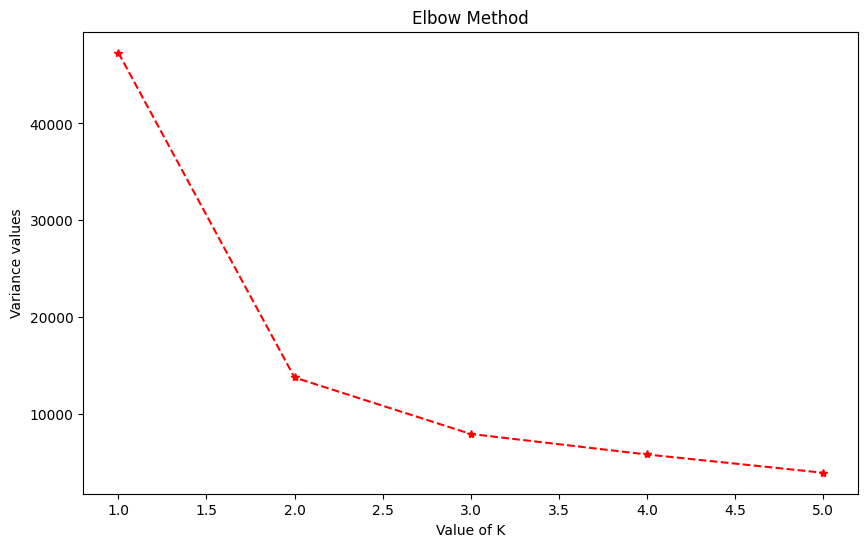

In [ ]:
# Visualizing elbow graph to find optimal k
plt.figure(figsize=(10,6))
plt.plot([1,2,3,4,5],variance,linestyle='--',color='red',marker='*')
plt.xlabel('Value of K')
plt.ylabel('Variance values')
plt.title('Elbow Method')
plt.show()

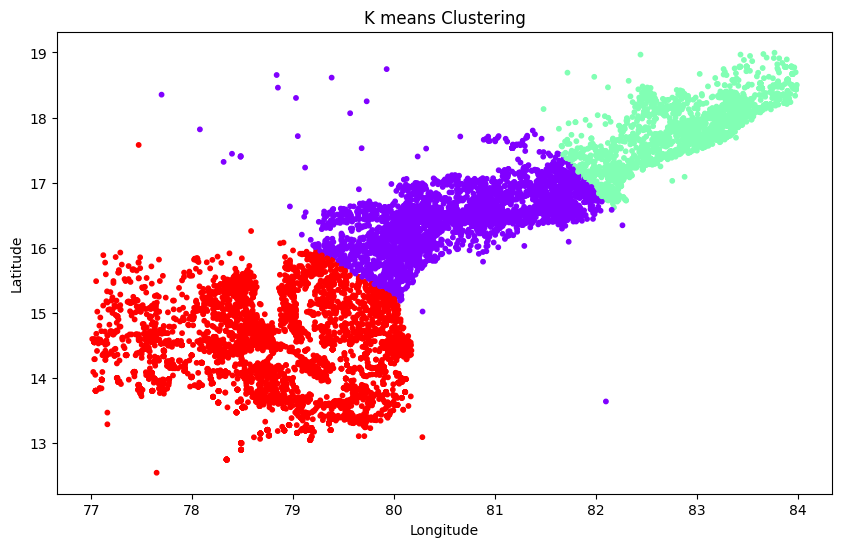

In [ ]:
# Acoording to the above graph we got the optimal value to be 3
label=assign_labels(final_cen[2],X) # Since we already saved the final centroids we use them to find the labels since I didn't store the labels 
                                    # correspponding to final centroids so this might have been done better but if we have many k's there might be \
                                    # an issue in storing them so I don't think so it's a worst idea to not to store 8000 labels for every k
# Visualizing the clustering made
plt.figure(figsize=(10,6))
# print(label)
plt.scatter(x=X[:,1],y=X[:,0],c=label,cmap="rainbow",s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K means Clustering")
plt.show()


In [ ]:
# Inference and insights
# In my perspective it's so cool because we also divide Andhra pradesh in these three regions which you see
# Green - Uttara Andhra ,  Violet - Coastal Andhra , Red -Rayalaseema
# The pincodes accurately divided Andhra pradesh into three parts which are based on geographically and politically also
# I got to know that pincodes have a deep geographical meaning rather than being a random number